In [1]:
from IPython.display import display, HTML
display(HTML("""
<style>
div.container{width:80% !important;}
div.CodeMirror {font-family:Consolas; font-size:12pt;}
div.output {font-size:12pt; font-weight:bold;}
div.input {font-family:Consolas; font-size:12pt;}
div.prompt {min-width:70px;}
div#toc-header{margin-top:150px;}
</style>
<style>
span.toc-item-num{
display:none;
}
</style>
"""))

# 9절. 데이터 그룹화 및 집계

In [2]:
import pandas as pd
import numpy as np
from statsmodels.api import datasets

In [3]:
iris = datasets.get_rdataset('iris').data
iris.head(1)
iris.iloc[[0,49,50,99,100,149]]

,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width,Species
0,5.1,3.5,1.4,0.2,setosa
49,5.0,3.3,1.4,0.2,setosa
50,7.0,3.2,4.7,1.4,versicolor
99,5.7,2.8,4.1,1.3,versicolor
100,6.3,3.3,6.0,2.5,virginica
149,5.9,3.0,5.1,1.8,virginica


## 9.1 group by
cf. pivot_table



In [4]:
# 1)그룹화방법 1 :df.groupby(by=[그룹핑할열])[함수적용해서 적용할 열들].기초통계함수()
                # [함수적용해서 출력할 열들]:모든 열이 적용됨
iris_grouped = iris.groupby(iris.Species)
iris_grouped_sum = iris_grouped.sum()
iris_grouped_sum

,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width
Species,,,,
setosa,250.3,171.4,73.1,12.3
versicolor,296.8,138.5,213.0,66.3
virginica,329.4,148.7,277.6,101.3


In [5]:
iris_grouped_sum.loc[['setosa','virginica']]

,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width
Species,,,,
setosa,250.3,171.4,73.1,12.3
virginica,329.4,148.7,277.6,101.3


In [6]:
print(iris_grouped_sum.columns)
print(iris_grouped_sum.index)

Index(['Sepal.Length', 'Sepal.Width', 'Petal.Length', 'Petal.Width'], dtype='object')
Index(['setosa', 'versicolor', 'virginica'], dtype='object', name='Species')


In [7]:
iris_grouped_sum.reset_index(inplace=True) # index를 컬럼 데이터로 편입

In [8]:
iris_grouped_sum

,Species,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width
0,setosa,250.3,171.4,73.1,12.3
1,versicolor,296.8,138.5,213.0,66.3
2,virginica,329.4,148.7,277.6,101.3


In [9]:
# iris_grouped_sum에서 setosa 그룹함수 결과만 추출
iris_grouped_sum[iris_grouped_sum['Species']=='setosa']
iris_grouped_sum[iris_grouped_sum.Species=='setosa']
iris_grouped_sum.loc[iris_grouped_sum.Species=='setosa']

,Species,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width
0,setosa,250.3,171.4,73.1,12.3


In [10]:
# iris_grouped_sum에서 setosa와 virginica 그룹함수 결과만 추출
iris_grouped_sum[(iris_grouped_sum.Species=='setosa')|(iris_grouped_sum.Species=='virginica')]

,Species,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width
0,setosa,250.3,171.4,73.1,12.3
2,virginica,329.4,148.7,277.6,101.3


In [11]:
iris_grouped_sum[iris_grouped_sum.Species.isin(['setosa','virginica'])]

,Species,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width
0,setosa,250.3,171.4,73.1,12.3
2,virginica,329.4,148.7,277.6,101.3


In [12]:
# 1)그룹화방법 1.1 : 그룹핑할 때 index를 컬럼 데이터로 편입(reset_index가 필요 x)
#df.groupby(by=[그룹핑할열],as_index=False)[함수적용해서 적용할 열들].기초통계함수()
     # [함수적용해서 출력할 열들]:모든 열이 적용됨
iris.groupby(iris.Species, as_index=False).sum()

,Species,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width
0,setosa,250.3,171.4,73.1,12.3
1,versicolor,296.8,138.5,213.0,66.3
2,virginica,329.4,148.7,277.6,101.3


In [13]:
# display(iris.groupby(iris.Species).sum())
display(iris.groupby(['Species']).sum())
#display(iris.groupby('Species').sum())

,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width
Species,,,,
setosa,250.3,171.4,73.1,12.3
versicolor,296.8,138.5,213.0,66.3
virginica,329.4,148.7,277.6,101.3


In [14]:
# 종별 sepal.length와 sepal.width의 평균
# iris.groupby('Species').mean()[['Sepal.Length','Sepal.Width']]
iris.groupby('Species')[['Sepal.Length','Sepal.Width']].mean()

,Sepal.Length,Sepal.Width
Species,,
setosa,5.006,3.428
versicolor,5.936,2.770
virginica,6.588,2.974


In [15]:
# 종별 Sepal.Length 의 합계
iris.groupby('Species')['Sepal.Length'].sum() # 결과가 시리즈 (1차원)

Species
setosa        250.3
versicolor    296.8
virginica     329.4
Name: Sepal.Length, dtype: float64

In [16]:
iris.groupby('Species')[['Sepal.Length']].sum() # 결과가 데이터 프레임

,Sepal.Length
Species,
setosa,250.3
versicolor,296.8
virginica,329.4


In [17]:
# 2) 그룹화 방법 2
# df.pivot_table(index='그룹화할 필드',
#                values=['함수적용해서 출력할 열들'],
#                aggfunc='함수명(기본값:mean)')

iris.pivot_table(index='Species')#종별평균들

,Petal.Length,Petal.Width,Sepal.Length,Sepal.Width
Species,,,,
setosa,1.462,0.246,5.006,3.428
versicolor,4.260,1.326,5.936,2.770
virginica,5.552,2.026,6.588,2.974


In [18]:
#iris.groupby('Species')[['Sepal.Length','Sepal.Width']].sum()
iris.pivot_table(index='Species',
                values=['Sepal.Length','Sepal.Width'],
                 aggfunc='sum')

,Sepal.Length,Sepal.Width
Species,,
setosa,250.3,171.4
versicolor,296.8,138.5
virginica,329.4,148.7


In [19]:
iris.groupby('Species').count() # 결측치를 제외한 데이터 갯수


,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width
Species,,,,
setosa,50,50,50,50
versicolor,50,50,50,50
virginica,50,50,50,50


In [20]:
iris.pivot_table(index='Species',
                aggfunc='count')# 결측치를 제외한 데이터 갯수

,Petal.Length,Petal.Width,Sepal.Length,Sepal.Width
Species,,,,
setosa,50,50,50,50
versicolor,50,50,50,50
virginica,50,50,50,50


In [21]:
import random
random.sample(range(len(iris)),3)

[44, 54, 10]

In [22]:
iris.shape[1]-1 # iris의 독립변수 열 갯수

4

In [23]:
# 각 열에 임의의 행에 결측치를 할당(0번째열은 결측치 1개, 1번째열은 결측치 2개, ... 3번째 열은 결측치 4개)
for col in range(iris.shape[1]-1):
    iris.iloc[random.sample(range(len(iris)),col+1),col] = np.nan

In [24]:
iris.groupby('Species').count()

,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width
Species,,,,
setosa,50,48,48,49
versicolor,50,50,50,49
virginica,49,50,49,48


In [25]:
result=iris.pivot_table(index='Species',
                aggfunc='count')
result=result[['Sepal.Length','Sepal.Width','Petal.Length','Petal.Width']]
result

,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width
Species,,,,
setosa,50,48,48,49
versicolor,50,50,50,49
virginica,49,50,49,48


In [26]:
iris['Species'].value_counts() #종별 데이터 갯수

setosa        50
versicolor    50
virginica     50
Name: Species, dtype: int64

### 다중열로 그룹화

In [27]:
iris.head(1)

,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width,Species
0,5.1,3.5,NaN,0.2,setosa


In [28]:
# iris로 다중열 그룹화 하기 위해서 데이터 추가(num 필드)
# iris의 행수가 150개 = Species 3그룹, num 6그룹
[[i]*25 for i in range(6)]



[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
 [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
 [2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2],
 [3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3],
 [4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4],
 [5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5]]

In [29]:
import numpy as np
iris['num']= np.ravel([[i]*25 for i in range(6)])
iris.iloc[::10]

,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width,Species,num
0,5.1,3.5,NaN,0.2,setosa,0
10,5.4,3.7,1.5,0.2,setosa,0
20,5.4,3.4,1.7,NaN,setosa,0
30,4.8,3.1,1.6,0.2,setosa,1
40,5.0,3.5,1.3,0.3,setosa,1
50,7.0,3.2,4.7,1.4,versicolor,2
60,5.0,2.0,3.5,1.0,versicolor,2
70,5.9,3.2,4.8,1.8,versicolor,2
80,5.5,2.4,3.8,1.1,versicolor,3
90,5.5,2.6,4.4,1.2,versicolor,3


In [30]:
# 종별, num별 합계
r = iris.groupby(by=['Species','num']).sum()
r

Sepal.Length  Sepal.Width  Petal.Length  Petal.Width
Species    num                                                      
setosa     0           125.7         82.6          33.6          6.0
           1           124.6         80.9          36.6          6.1
versicolor 2           150.3         69.4         107.8         33.6
           3           146.5         69.1         105.2         31.4
virginica  4           159.5         73.2         135.3         49.3
           5           165.0         75.5         136.6         47.9

In [31]:

r.index

MultiIndex([(    'setosa', 0),
            (    'setosa', 1),
            ('versicolor', 2),
            ('versicolor', 3),
            ( 'virginica', 4),
            ( 'virginica', 5)],
           names=['Species', 'num'])

In [32]:
r.loc[['setosa','virginica']] # setosa와 virginica만 결과 추출

Sepal.Length  Sepal.Width  Petal.Length  Petal.Width
Species   num                                                      
setosa    0           125.7         82.6          33.6          6.0
          1           124.6         80.9          36.6          6.1
virginica 4           159.5         73.2         135.3         49.3
          5           165.0         75.5         136.6         47.9

In [33]:
# 종별, num별 중위수 ('Species','num'이 컬럼 데이터로 편입)
r = iris.groupby(by=['Species','num'], as_index=False).median()
r


,Species,num,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width
0,setosa,0,5.0,3.4,1.50,0.20
1,setosa,1,5.0,3.4,1.50,0.20
2,versicolor,2,6.1,2.8,4.50,1.40
3,versicolor,3,5.7,2.8,4.20,1.30
4,virginica,4,6.5,2.9,5.55,2.05
5,virginica,5,6.4,3.0,5.50,1.95


In [34]:
# setosa와 virginica 추출
r[(r['Species']=='setosa')|(r['Species']=='virginica')]
r[r['Species'].isin(['setosa','virginica'])]

,Species,num,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width
0,setosa,0,5.0,3.4,1.50,0.20
1,setosa,1,5.0,3.4,1.50,0.20
4,virginica,4,6.5,2.9,5.55,2.05
5,virginica,5,6.4,3.0,5.50,1.95


In [35]:
# iris.groupby(by=['Species','num']).sum 과 동일
iris.pivot_table(index=['Species','num'],
                #values=[],
                aggfunc='sum')

Petal.Length  Petal.Width  Sepal.Length  Sepal.Width
Species    num                                                      
setosa     0            33.6          6.0         125.7         82.6
           1            36.6          6.1         124.6         80.9
versicolor 2           107.8         33.6         150.3         69.4
           3           105.2         31.4         146.5         69.1
virginica  4           135.3         49.3         159.5         73.2
           5           136.6         47.9         165.0         75.5

In [36]:
# 종별 기초 통계량(min,max,count,mean,median,Q1,Q3,sed...)모두
iris.groupby(['Species']).describe()


Sepal.Length                                               \
                  count      mean       std  min  25%  50%  75%  max   
Species                                                                
setosa             50.0  5.006000  0.352490  4.3  4.8  5.0  5.2  5.8   
versicolor         50.0  5.936000  0.516171  4.9  5.6  5.9  6.3  7.0   
virginica          49.0  6.622449  0.593459  5.6  6.3  6.5  6.9  7.9   

           Sepal.Width           ... Petal.Width        num                 \
                 count     mean  ...         75%  max count mean       std   
Species                          ...                                         
setosa            48.0  3.40625  ...         0.3  0.6  50.0  0.5  0.505076   
versicolor        50.0  2.77000  ...         1.5  1.8  50.0  2.5  0.505076   
virginica         50.0  2.97400  ...         2.3  2.5  50.0  4.5  0.505076   

                                     
            min  25%  50%  75%  max  
Species                              
setosa      0.0  0.0  0.5  1.0  1.0  
versicolor  2.0  2.0  2.5  3.0  3.0  
virginica   4.0  4.0  4.5  5.0  5.0  

[3 rows x 40 columns]

In [37]:
iris.groupby(['Species']).describe().T

Species                setosa  versicolor  virginica
Sepal.Length count  50.000000   50.000000  49.000000
             mean    5.006000    5.936000   6.622449
             std     0.352490    0.516171   0.593459
             min     4.300000    4.900000   5.600000
             25%     4.800000    5.600000   6.300000
             50%     5.000000    5.900000   6.500000
             75%     5.200000    6.300000   6.900000
             max     5.800000    7.000000   7.900000
Sepal.Width  count  48.000000   50.000000  50.000000
             mean    3.406250    2.770000   2.974000
             std     0.359317    0.313798   0.322497
             min     2.300000    2.000000   2.200000
             25%     3.175000    2.525000   2.800000
             50%     3.400000    2.800000   3.000000
             75%     3.625000    3.000000   3.175000
             max     4.200000    3.400000   3.800000
Petal.Length count  48.000000   50.000000  49.000000
             mean    1.462500    4.260000   5.548980
             std     0.177002    0.469911   0.557196
             min     1.000000    3.000000   4.500000
             25%     1.400000    4.000000   5.100000
             50%     1.500000    4.350000   5.500000
             75%     1.600000    4.600000   5.900000
             max     1.900000    5.100000   6.900000
Petal.Width  count  49.000000   49.000000  48.000000
             mean    0.246939    1.326531   2.025000
             std     0.106266    0.199766   0.275604
             min     0.100000    1.000000   1.400000
             25%     0.200000    1.200000   1.800000
             50%     0.200000    1.300000   2.000000
             75%     0.300000    1.500000   2.300000
             max     0.600000    1.800000   2.500000
num          count  50.000000   50.000000  50.000000
             mean    0.500000    2.500000   4.500000
             std     0.505076    0.505076   0.505076
             min     0.000000    2.000000   4.000000
             25%     0.000000    2.000000   4.000000
             50%     0.500000    2.500000   4.500000
             75%     1.000000    3.000000   5.000000
             max     1.000000    3.000000   5.000000

In [38]:

g= iris.groupby(['Species'])[['Sepal.Length','Sepal.Width','Petal.Length','Petal.Width']].mean()

g

,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width
Species,,,,
setosa,5.006000,3.40625,1.46250,0.246939
versicolor,5.936000,2.77000,4.26000,1.326531
virginica,6.622449,2.97400,5.54898,2.025000


https://stackoverflow.com/questions/30490740/move-legend-outside-figure-in-seaborn-tsplot: 범례사용

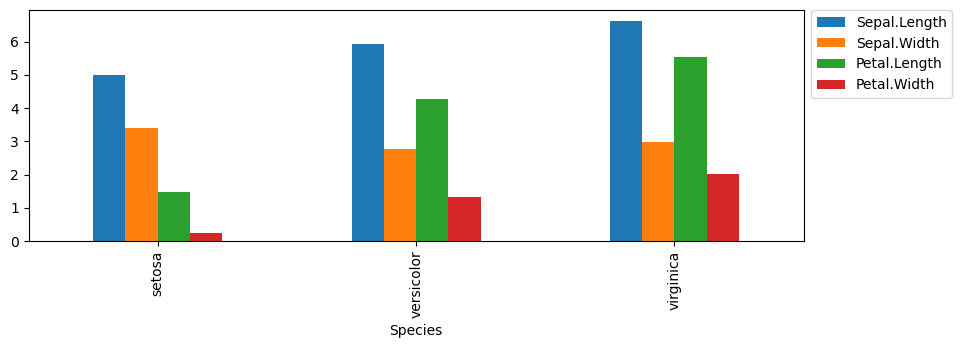

In [39]:
import matplotlib.pyplot as plt
g.plot(kind='bar',figsize=(10,3))
plt.legend(bbox_to_anchor=(1.01,1),loc=2,borderaxespad=0.)


In [40]:
# 종별,num별 평균
g = iris.groupby(['Species','num']).mean()
g

Sepal.Length  Sepal.Width  Petal.Length  Petal.Width
Species    num                                                      
setosa     0        5.028000     3.441667       1.46087     0.250000
           1        4.984000     3.370833       1.46400     0.244000
versicolor 2        6.012000     2.776000       4.31200     1.344000
           3        5.860000     2.764000       4.20800     1.308333
virginica  4        6.645833     2.928000       5.63750     2.054167
           5        6.600000     3.020000       5.46400     1.995833

In [41]:
# g의 level0 인덱스만 그대로 두고, level1인덱스를 컬럼값으로 올려
g.unstack().T

Species             setosa  versicolor  virginica
             num                                 
Sepal.Length 0    5.028000         NaN        NaN
             1    4.984000         NaN        NaN
             2         NaN    6.012000        NaN
             3         NaN    5.860000        NaN
             4         NaN         NaN   6.645833
             5         NaN         NaN   6.600000
Sepal.Width  0    3.441667         NaN        NaN
             1    3.370833         NaN        NaN
             2         NaN    2.776000        NaN
             3         NaN    2.764000        NaN
             4         NaN         NaN   2.928000
             5         NaN         NaN   3.020000
Petal.Length 0    1.460870         NaN        NaN
             1    1.464000         NaN        NaN
             2         NaN    4.312000        NaN
             3         NaN    4.208000        NaN
             4         NaN         NaN   5.637500
             5         NaN         NaN   5.464000
Petal.Width  0    0.250000         NaN        NaN
             1    0.244000         NaN        NaN
             2         NaN    1.344000        NaN
             3         NaN    1.308333        NaN
             4         NaN         NaN   2.054167
             5         NaN         NaN   1.995833

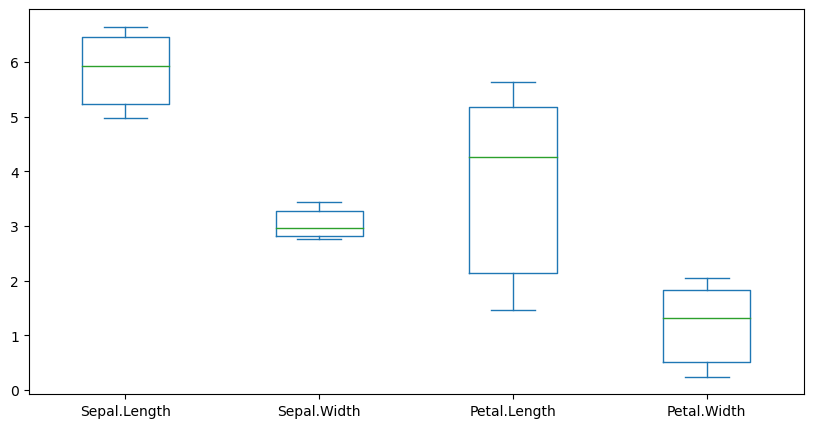

In [42]:
g.plot(kind='box',figsize=(10,5))
plt.show()

## 9.2 그룹간 데이터 처리

In [43]:
iris_grouped = iris.groupby('Species')
iris_grouped

In [44]:
for speciename, group in iris_grouped:
    print(speciename)
    print(group.head(3))
    print('■■■■■■■■■■■■■■■■■■■■■')

setosa
   Sepal.Length  Sepal.Width  Petal.Length  Petal.Width Species  num
0           5.1          3.5           NaN          0.2  setosa    0
1           4.9          3.0           1.4          0.2  setosa    0
2           4.7          3.2           1.3          0.2  setosa    0
■■■■■■■■■■■■■■■■■■■■■
versicolor
    Sepal.Length  Sepal.Width  Petal.Length  Petal.Width     Species  num
50           7.0          3.2           4.7          1.4  versicolor    2
51           6.4          3.2           4.5          1.5  versicolor    2
52           6.9          3.1           4.9          1.5  versicolor    2
■■■■■■■■■■■■■■■■■■■■■
virginica
     Sepal.Length  Sepal.Width  Petal.Length  Petal.Width    Species  num
100           6.3          3.3           6.0          2.5  virginica    4
101           5.8          2.7           5.1          1.9  virginica    4
102           7.1          3.0           5.9          2.1  virginica    4
■■■■■■■■■■■■■■■■■■■■■


In [45]:
# 종별 임의의 표본 5개씩 출력
# iris.sample(5).sort_index()
for idx, (speciename,group) in enumerate(iris_grouped):
    print('{}번째 그룹은{}'.format(idx,speciename))
    display(group.sample(5).sort_index())

0번째 그룹은setosa


,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width,Species,num
8,4.4,2.9,1.4,0.2,setosa,0
14,5.8,4.0,1.2,0.2,setosa,0
15,5.7,NaN,1.5,0.4,setosa,0
18,5.7,3.8,1.7,0.3,setosa,0
30,4.8,3.1,1.6,0.2,setosa,1


1번째 그룹은versicolor


,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width,Species,num
60,5.0,2.0,3.5,1.0,versicolor,2
76,6.8,2.8,4.8,1.4,versicolor,3
85,6.0,3.4,4.5,1.6,versicolor,3
86,6.7,3.1,4.7,1.5,versicolor,3
95,5.7,3.0,4.2,1.2,versicolor,3


2번째 그룹은virginica


,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width,Species,num
123,6.3,2.7,4.9,NaN,virginica,4
133,6.3,2.8,5.1,1.5,virginica,5
138,6.0,3.0,4.8,1.8,virginica,5
144,6.7,3.3,5.7,2.5,virginica,5
146,6.3,2.5,5.0,1.9,virginica,5


In [46]:
# 종별  0,10,20,30,40번째 데이터 출력: s:10,20,30,40행, vc:50,60,70,80,90, vn:100,110
for speciename,group in iris_groupby('Species'):
    print(speciename,'그룹')
    print(group.iloc[[0,10,20,30,40]])

NameError: name 'iris_groupby' is not defined

## 9.4 레이블(원핫인코딩)


In [ ]:
iris.drop('num',axis=1, inplace=True)

In [ ]:
iris.head()

In [ ]:
# 레이블(원핫인코딩)을 지원하는 패키지 이용
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder() # 객체
iris['target'] = le.fit_transform(iris.Species)
iris.iloc[::25]

# 10절. 데이터 구조 변경
## 10.1 와이드포맷<->롱포맷
- 판다스 공식문서에 나오는melt:https://pandas.pydata.org/docs/user_guide/reshaping.html#reshaping-by-melt

- [Tidy Data 란?](https://vita.had.co.nz/papers/tidy-data.pdf ) 7page


In [58]:
import statsmodels.api as sm
airqulity = sm.datasets.get_rdataset('airquality',package='datasets').data
airqulity

,Ozone,Solar.R,Wind,Temp,Month,Day
0,41.0,190.0,7.4,67,5,1
1,36.0,118.0,8.0,72,5,2
2,12.0,149.0,12.6,74,5,3
3,18.0,313.0,11.5,62,5,4
4,NaN,NaN,14.3,56,5,5
...,...,...,...,...,...,...
148,30.0,193.0,6.9,70,9,26
149,NaN,145.0,13.2,77,9,27
150,14.0,191.0,14.3,75,9,28
151,18.0,131.0,8.0,76,9,29


## 10.2 melt를 이용한 언피벗팅(와이드포맷->롱포맷)

In [59]:
airqulity_melted= airqulity.melt(id_vars=['Month','Day'])
airqulity_melted

,Month,Day,variable,value
0,5,1,Ozone,41.0
1,5,2,Ozone,36.0
2,5,3,Ozone,12.0
3,5,4,Ozone,18.0
4,5,5,Ozone,NaN
...,...,...,...,...
607,9,26,Temp,70.0
608,9,27,Temp,77.0
609,9,28,Temp,75.0
610,9,29,Temp,76.0


In [60]:
airqulity_melted=airqulity.melt(id_vars=['Month','Day'], 
               var_name='변수명',# melt된 열의 이름
               value_name='값') # 데이터가 된 열의 이름
airqulity_melted.sort_values(by=['Month','Day'])
airqulity_melted.reset_index()

,index,Month,Day,변수명,값
0,0,5,1,Ozone,41.0
1,1,5,2,Ozone,36.0
2,2,5,3,Ozone,12.0
3,3,5,4,Ozone,18.0
4,4,5,5,Ozone,NaN
...,...,...,...,...,...
607,607,9,26,Temp,70.0
608,608,9,27,Temp,77.0
609,609,9,28,Temp,75.0
610,610,9,29,Temp,76.0


### melt 연습하기

In [47]:
import pandas as pd
df_first = pd.read_csv(r'D:\ai\Downloads\shareData\전국 평균 평당 분양가격(2013년 9월부터 2015년 8월까지).csv',encoding='cp949')
df_last = pd.read_csv(r'D:\ai\Downloads\shareData\주택도시보증공사_전국 신규 민간아파트 분양가격 동향_20240731.csv',encoding='cp949')
df_first.shape, df_last.shape

((17, 22), (9010, 5))

In [48]:
df_first.head(5) # => new_first(지역명, 연도, 월, 평당분양가격(제곱미터))

,지역,2013년12월,2014년1월,2014년2월,2014년3월,2014년4월,2014년5월,2014년6월,2014년7월,2014년8월,...,2014년11월,2014년12월,2015년1월,2015년2월,2015년3월,2015년4월,2015년5월,2015년6월,2015년7월,2015년8월
0,서울,18189,17925,17925,18016,18098,19446,18867,18742,19274,...,20242,20269,20670,20670,19415,18842,18367,18374,18152,18443
1,부산,8111,8111,9078,8965,9402,9501,9453,9457,9411,...,9208,9208,9204,9235,9279,9327,9345,9515,9559,9581
2,대구,8080,8080,8077,8101,8267,8274,8360,8360,8370,...,8439,8253,8327,8416,8441,8446,8568,8542,8542,8795
3,인천,10204,10204,10408,10408,10000,9844,10058,9974,9973,...,10020,10020,10017,9876,9876,9938,10551,10443,10443,10449
4,광주,6098,7326,7611,7346,7346,7523,7659,7612,7622,...,7752,7748,7752,7756,7861,7914,7877,7881,8089,8231


In [49]:
df_last.head(1) # => new_last(모든 면적 행만 지역명,연도 , 월,분양가격(제곱미터))

,지역명,규모구분,연도,월,분양가격(제곱미터)
0,서울,모든면적,2015,10,5841


In [50]:
# 지역 연도 월 평당분양가격 식의 롱포맷 데이터로 바꾸기
new_first=df_first.melt(id_vars=['지역'],
             var_name='연도월',
             value_name='평당분양가격')
new_first.sample(1)

,지역,연도월,평당분양가격
91,울산,2014년5월,8153


In [51]:
# 연도월 컬럼을 연도, 월로 분리 
def parse_year(x):
    return int(x.split('년')[0])
parse_year("2013년12월")

2013

In [52]:
# new_first['연도월'].map(lambda x : int(x.split('년')[0])) #map은 1차원에서 가능
new_first['연도']=new_first['연도월'].apply(lambda x : int(x.split('년')[0])) # apply는 1,2차원 모두 가능
new_first.head(1)

,지역,연도월,평당분양가격,연도
0,서울,2013년12월,18189,2013


In [53]:
new_first['월']=new_first['연도월'].apply(lambda x : int(x.split('년')[-1][:-1]))
new_first.head(1)

,지역,연도월,평당분양가격,연도,월
0,서울,2013년12월,18189,2013,12


In [54]:
# 평당분양가격/3.3 => 분양가격(제곱미터)
new_first.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 357 entries, 0 to 356
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   지역      357 non-null    object
 1   연도월     357 non-null    object
 2   평당분양가격  357 non-null    int64 
 3   연도      357 non-null    int64 
 4   월       357 non-null    int64 
dtypes: int64(3), object(2)
memory usage: 14.1+ KB


In [55]:
new_first['분양가격(제곱미터)'] = new_first['평당분양가격']/3.3
new_first.sample(1)

,지역,연도월,평당분양가격,연도,월,분양가격(제곱미터)
271,제주,2015년3월,7826,2015,3,2371.515152


In [ ]:
# 불필요한 필드 삭제, column명을 지역 -> 지역명
new_first.drop(['연도월','평당분양가격'],axis=1,inplace=True)
new_first.columns=['지역명','연도','월','분양가격(제곱미터)']
new_first.head()

In [ ]:
#df_last => new_last(모든 면적 행만 지역명,연도 , 월,분양가격(제곱미터))
new_last = df_last[df_last['규모구분']=='모든면적']
new_last.head(1)

In [ ]:
# new_last의 규모 구분 열 삭제
new_last.drop('규모구분', axis=1)

In [ ]:
new_last.head(1)

In [ ]:
df = pd.concat([new_first,new_last])
df.head()

## 10.3 pivot_table을 이용한 피벗팅(롱포맷->와이드포맷)

In [61]:
airqulity_melted= airqulity.melt(id_vars=['Month','Day'])
airqulity_melted=airqulity_melted.sort_values(['Month','Day']).reset_index(drop=True)
airqulity_melted.head()

,Month,Day,variable,value
0,5,1,Ozone,41.0
1,5,1,Solar.R,190.0
2,5,1,Wind,7.4
3,5,1,Temp,67.0
4,5,2,Ozone,36.0


In [62]:
airqulity2 =airqulity_melted.pivot_table(index=['Month','Day'],
                            columns=['variable'],
                            values=['value'])
airqulity2.head()

value                    
variable  Ozone Solar.R  Temp  Wind
Month Day                          
5     1    41.0   190.0  67.0   7.4
      2    36.0   118.0  72.0   8.0
      3    12.0   149.0  74.0  12.6
      4    18.0   313.0  62.0  11.5
      5     NaN     NaN  56.0  14.3

In [63]:
airqulity2.reset_index(level=['Month','Day'],col_level=1,inplace=True)
airqulity2.head()

value                    
variable Month Day Ozone Solar.R  Temp  Wind
0            5   1  41.0   190.0  67.0   7.4
1            5   2  36.0   118.0  72.0   8.0
2            5   3  12.0   149.0  74.0  12.6
3            5   4  18.0   313.0  62.0  11.5
4            5   5   NaN     NaN  56.0  14.3

In [ ]:
airqulity2.columns=airqulity2.columns.droplevel(level=0) # 0번 level의 컬럼 제거
airqulity2.head()

In [ ]:
airqulity2.columns.name=''
airqulity2.head(1)

### pivot_table(),pivot() 함수차이

In [ ]:
import numpy as np
year = [2020]*3+[2021]*3
mon = [1,2,3] *2
latte=[410,401,402,400,404,405]
americano=[500,483,484,470,486,488]
mocha=[350,299,300,301,302,300]
sales = pd.DataFrame(np.c_[year,mon,latte,americano,mocha],
                    columns=['year','mon','latte','americano','mocha'])
sales

In [ ]:
sales.groupby(['year'])[['latte','americano','mocha']].sum()

In [ ]:
result = sales.pivot_table(index='year',
                 values=['latte','americano','mocha'],
                 aggfunc='sum')
result

In [ ]:
result.loc[2021]

In [ ]:
# pivot()
sales = sales.loc[:,'year':'latte']
sales

In [ ]:
sales.pivot(index='year',columns='mon')

# 11절. 데이터프레임에 함수 적용시키기
- apply: (데이터프레임이나 시리즈 모두 적용가능)
- applymap(func): 각 요소별로 함수를 적용(데이터 프레임에서만 가능)
- map(func): 각 요소별로 함수를 적용(1차원시리즈에서만 가능)

## 11.1 apply

In [ ]:
# ex1. 1차원 시리즈에서 사용
member = pd.read_csv('data/ch12_member.csv', comment='#')

In [ ]:
def get_month(str):
    return int(str.split('-')[1])
get_month('2000-01-01')

In [ ]:
member[member['Birth'].apply(lambda str : int(str.split('-')[1])) ==1]

In [ ]:
# ex2. 2차원 데이터 프레임에 apply적용 (axis)
df_last

In [ ]:
df_last.loc[0]

In [ ]:
def year_month(series):
    return str(series['연도'])+'년'+str(series['월'])+'월'
year_month(df_last.loc[0])

In [ ]:
df_last['연도월']\
    =df_last.apply(lambda series :str(series['연도'])+'년'+str(series['월'])+'월',axis=1)
df_last.head(1)

In [ ]:
# ex3 iris 데이터의 apply
import seaborn as sns
iris = sns.load_dataset('iris')
iris.head()

In [ ]:
X= iris.iloc[:,:-1]
X.head()

In [ ]:
X.apply(np.sum,axis=0) #열별 sum

In [ ]:
X.apply(np.sum, axis=1) # 행별 sum

In [ ]:
# X의 열별 평균 
avg = X.apply(np.average,axis =0)
avg

In [ ]:
X.apply(lambda x : round(x-avg,2), axis=1)

In [ ]:
X.apply(lambda x : list(round(x-avg,2)), axis=1)

## 11.2 applymap

In [ ]:
X.applymap(np.round)

In [ ]:
X.applymap(lambda x :x**2)

In [ ]:
# ex1. 1차원 시리즈에서 사용
member = pd.read_csv('data/ch12_member.csv', comment='#')
member.head(1)

In [ ]:
member['Birth'].map(lambda date_str : int(date_str.split('-')[1]))

# 12절. 데이터 일괄 변경하기(결측치나 특정값)
## 12.1 fillna(결측치를  어떤 값으로 바꿈)
- 대부분의 결측치는 drop하거나, 평균값대체, 최빈값대체, 중위수대체, 그룹별 평균값, 이전값으로 대체, 다음값으로 대체, 회귀식결과 값으로 대체함

In [ ]:
df = pd.DataFrame([[np.nan,2,np.nan,0],
                  [3,     4,np.nan,1],
                  [np.nan,3,np.nan,5],
                  [np.nan,3,np.nan,4]],
                 columns=list('ABCD'))
df

In [ ]:
# 모든 결측치를 무조건 0으로 대체
df.fillna(0)

In [ ]:
# 결측치를 이전행의 값으로 대체
df.fillna(method='ffill')

In [ ]:
# 결측치를 다른행의 값으로 대체
df.fillna(method='bfill')

In [ ]:
# 결측치를 특정 대체값으로 바꿈
values = {'A':99,'B':98,'C':97,'D':96}
df.fillna(value=values)

In [ ]:
#결측치를 열별 평균으로 바꿈
df.fillna(value=df.mean(axis=0))

In [ ]:
df.fillna(value=values, limit =3) # 결측치 대체는 3번째 행까지만)

## 12.2 replace(to_value,new_value, inplace=T/F
- to_value를 new_value로 변경
- 정규표현식을 이용가능

In [ ]:
s = pd.Series([0,1,2,3,None])
s.replace(np.nan,0, inplace= True)
s.replace([0,1],99) # 0이나 1을 99로 변경

In [ ]:
s = pd.Series([0,1,2,3,None])
s

In [ ]:
df = pd.DataFrame({'A':['bat','foo','bait'],
                 'b':['abc','bar','xyz']})

In [ ]:
df.replace(r'^ba.+$','xxx',regex=True)

In [ ]:
df.replace({'A':'bat','B':'abc'},'XXX')


## 12.3 where(조건),mask(조건)
    - where(조건): 조건이 만족하는 요소는 그대로 출력하고 만족하지 않는 요소는 결측치로
    - mask(조건): where와의 반대

In [ ]:
s = pd.Series(range(10,20))
s

In [ ]:
s[s>15]# 15초과값 출력

In [ ]:
s.where(s>15) # 조건이 만족되는 데이터는 그대로 출력. 만족되지 않은 데이터는 결측치

In [ ]:
s.mask(s>15)

## 12.4 dropna
- 결측치가 있는 데이터 누락 (행기준, 열기준)


In [ ]:
df= pd.DataFrame({'name':['홍','김','이',np.nan],
                 'age':[np.nan,20,30,np.nan],
                 'born':['서울','부산',np.nan,np.nan]})
df

In [ ]:
df.dropna() # 결측치가 하나라도 있는 행은 제거 inplace=True가 아니면 return

In [ ]:
df.dropna(subset=['name','age'])#name열과 age열에 결측치가 하나라도 있는 행 제거

In [ ]:
df.dropna(how='all') # 모두 결측치인 행만 삭제

In [ ]:
df.dropna(axis=1) #결측치가 하나라도 있으면 삭제

In [ ]:
df.dropna(axis=1,how='all') # 모두 결측치인 열만 삭제

## 12절 연습문제

In [ ]:
import random
print(random.sample(range(150),20))

In [ ]:
iris = datasets.get_rdataset('iris').data
iris

In [ ]:
# 1단계
for col in range(iris.shape[1]-1):
    iris.iloc[random.sample(range(150),20),col] = np.nan
iris

In [ ]:
#2단계 
iris.isna().sum()

In [ ]:
iris['Sepal.Length'].isna()

In [ ]:
# 3단계 : 결측치를 열평균으로 대체된 iris데이터를 출력한다(inplace=True)
iris.mean()

In [ ]:
iris.fillna(value=iris.iloc[:,:-1].mean(axis=0),inplace=True)

iris.head()

In [ ]:
import seaborn as sns
iris = sns.load_dataset("iris")
type(iris)

In [ ]:
iris.head()

# 13절 . 시리즈
- 1차원 데이터

In [ ]:
s = pd.Series([1000,7000,5000,2000,1500],
             index=['apple','mango','banana','cherry','orange'])
s

In [ ]:
s['apple'],s.apple

In [ ]:
s['apple':'banana'] # 슬라이싱(mango 포함) iloc x

In [ ]:
s[['apple','banana']] # mango 미포함

In [ ]:
s['watermelon']= 20000 # 시리즈에 데이터 추가
s['apple'] =3000 # 시리즈에 데이터 수정
s

In [ ]:
s.drop('watermelon',inplace=True)

In [ ]:
s

In [ ]:
s.sort_index(inplace=True) # 이름에 의한 정렬
s

In [ ]:
s.sort_values(inplace=True) # 값에 의한 정렬
s

In [ ]:
s.to_frame() # 시리즈를 데이터 프레임으로 변환

In [ ]:
s.to_frame(name='price') # 열이름을 지정하여 데이터 프레임으로 전환

# 연습문제 실습형

In [ ]:
import seaborn as sns
iris = sns.load_dataset("iris")
type(iris)

In [ ]:
# 1.iris 데이터에서 처음 다섯개 행만 출력하세요
iris.head()
iris.loc[:4]
iris.iloc[:5]


In [ ]:
#2.iris 데이터를 데이터프레임 변수인 독립변수 X와 종속변수 y로 나누세요. 
#   종속변수는 species 열입니다.
X = iris.iloc[:,:-1]
y = iris.iloc[:,-1:]

display(X)
display(y)

In [ ]:
# 3.iris 데이터에서 처음 50개행을 빼내서 temp변수에 저장하세요
temp = iris.iloc[:50]

In [ ]:
# 4. 3번에서 선택한 데이터프레임의 요약정보를 출력하세요. 모든 열에 대해 요약정보가
#    출력되어야 합니다.
temp.describe()

In [ ]:
# 5. versicolor종의 데이터만 iris_versicolor변수에 저장하세요
iris_versicolor = iris.loc[iris['species'].str.contains('versicolor')]

iris_versicolor.head()

In [ ]:
#6. 2번의 X와 y변수를 합해서 iris_df데이터 프레임으로 만드세요
import pandas as pd
iris_df = pd.concat([X,y],axis=1)
iris_df

In [ ]:
# 7. iris 데이터의 각 열 평균값을 출력하세요.
X.mean(numeric_only=True, axis=1)
X.mean()

In [ ]:
# 8. iris 데이터의 각 열들 사이의 상관계수를 출력하세요
X.corr()

In [ ]:
# 9. iris 데이터에서 각 요소들과 변수별 평균과의 차이를 출력하세요.
X.apply(lambda x : round(x-X.mean(),2), axis=1)

In [ ]:
# 10. iris 데이터의 종별 평균을 출력하세요
a = iris.pivot_table(index='species')
a

In [ ]:
b = iris.groupby(['species']).mean()
b

In [ ]:
a.loc['setosa']

In [ ]:
seto = iris.apply(lambda x : x-a.loc['setosa'], axis=1)[:3]

In [ ]:
versi = iris.apply(lambda x : x-a.loc['versicolor'], axis=1)[50:53]

In [ ]:
virg = iris.apply(lambda x : x-a.loc['virginica'], axis=1)[100:103]

In [ ]:
pd.concat([seto,versi,virg])